In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r"C:\Users\Charan\Desktop\JavaScript\Internship\TAKEITSMART\NetFlix.csv")

In [ ]:
df

In [ ]:
print(df=='NaN')

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df['director'].fillna('None',inplace=True)

In [ ]:
df['cast'].fillna('None',inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
df['country'].fillna('None',inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
df['date_added']=pd.to_datetime(df['date_added'])

In [ ]:
df['year']=df['date_added'].dt.year

In [ ]:
df.head()
df['listed_in'] = "Unknown"

In [ ]:
total_titles = df.shape[0]
print("Total_titles:",total_titles)
print(df.columns)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.countplot(x='type',data = df)
plt.title('Movies vs tvshows')
plt.show()
df['year']=df['date_added'].dt.year

In [ ]:
year_counts = df['year'].value_counts().sort_index()
# print(df.head(10))
plt.figure(figsize=(6,6))
year_counts.plot(kind='line')
plt.title("Content added over years")
plt.xlabel("Year")
plt.ylabel("Titles")
plt.show()

In [ ]:
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values , y=top_countries.index)
plt.title("Contries vs no of movies")
plt.xlabel("No of movies")
plt.ylabel("Countries")
plt.show()

In [ ]:
# df['listed_in'] = ['Drama','Comedy','Action','Thriller']
# top_countries = df['listed_in'].value_counts().head(10)
# sns.barplot(x=top_countries.values , y=top_countries.index)
# plt.title("Genre vs movies")
# plt.xlabel("No of movies")
# plt.ylabel("Genre")
# plt.show()

In [ ]:
top_rating = df['rating'].value_counts().head(10)
print(top_rating)


In [ ]:
india=df[df['country'].str.contains("India",na=False)] 
usa =df[df['country'].str.contains("United states",na=False)] 

In [ ]:
top_genre_india = india['listed_in'].str.split(',').explode().str.strip().value_counts().head()
top_genre_usa = usa['listed_in'].str.split(',').explode().str.strip().value_counts().head()
print(top_genre_india)
print(top_genre_usa)

In [ ]:
top_directors = (df['director'].dropna()                 
    .str.split(',')           
    .explode()               
    .str.strip()             
    .value_counts()       
    .head()            
)

print(top_directors)

In [ ]:
top_directors = (
    df['director']
    .dropna()
)

print(top_directors)

In [ ]:
top_directors = (df['director'].dropna()                 
    .str.split(',')           
    .explode()               
    .str.strip()             
    .value_counts()       
    .head()            
)

print(top_directors)

In [ ]:
top_directors = (
    df['director']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts(dropna=True)
    .head()
)

print(top_directors)

In [ ]:
top_directors = (
    df['director']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head()
)

print(top_directors)

In [ ]:
top_directors = (
    df['director']
    .replace('None', pd.NA)  
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head()
)

print(top_directors)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import pandas as pd

In [ ]:
ages =np.array([2,3,5,7,9,11,12,11,17,20,19,23]).reshape(12,1)
h = np.array([55,65,75,85,86,95,120,110,130,155,180,185])
print(ages ,h )

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

ages =np.array([2,3,5,7,9,11,12,11,17,20,19,23])
heights = np.array([55,65,75,85,86,95,120,110,130,155,180,185])
h = []
for i in heights:
    if i <= 100:
        h.append(0)
    elif i <= 140:
        h.append(1)
    else:
        h.append(2)

h = np.array(h)
ages = ages.reshape(-1, 1)
model = LogisticRegression(multi_class="multinomial")
model.fit(ages, h)

In [ ]:
import matplotlib.pyplot as plt
age_range = np.linspace(4,19,200).reshape(-1,1)
predict = model.predict(age_range)
plt.figure(figsize=(8,6))
plt.scatter(ages.flatten(), heights, c=h, cmap='viridis', s=100)
plt.plot(age_range,predict,color='black')
plt.xlabel("Age")
plt.ylabel("Height")
plt.title("Age vs Height Classification")
plt.colorbar(label="Height Category")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv(r"C:\Users\Charan\Downloads\winequality.csv") 

In [ ]:
df

In [ ]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

print(df.head())


In [ ]:
corr_matrix = df.corr()

In [ ]:
quality_corr = corr_matrix['quality'].sort_values(ascending=False)
print("\nCorrelation with Quality:\n")
print(quality_corr)


In [ ]:
plt.figure()
quality_corr.drop('quality').plot(kind='bar')
plt.title("Correlation Between Chemical Properties and Wine Quality")
plt.xlabel("Chemical Properties")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Results:")
print("MSE:", lr_mse)
print("R2 Score:", lr_r2)


In [ ]:

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality (Random Forest)")
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Charan\Desktop\JavaScript\Internship\TAKEITSMART\insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df_numerical = df

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
num_data =df.select_dtypes(include = ['int64','float64'])
num_data

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [8]:
character_data = df.select_dtypes(include=["object"])
character_data

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [9]:
df.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
import seaborn as sns

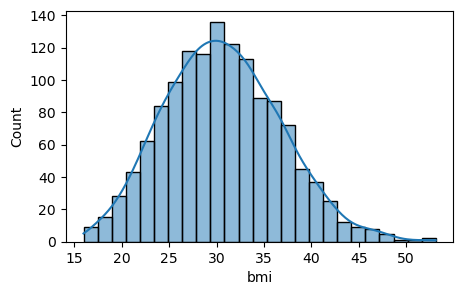

In [12]:
plt.figure(figsize=(5,3))
sns.histplot(df,x="bmi",kde=True)
plt.show()

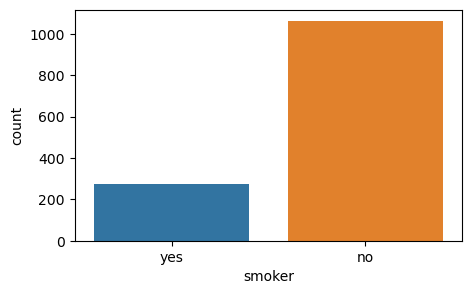

In [13]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='smoker')
plt.show()

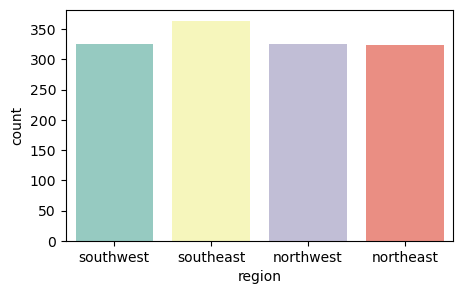

In [14]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='region',palette="Set3")
plt.show()

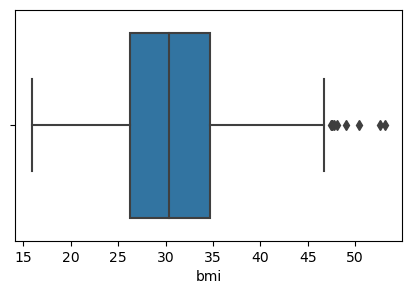

In [15]:
plt.figure(figsize=(5,3))
sns.boxplot(x='bmi', data=df)
plt.show()

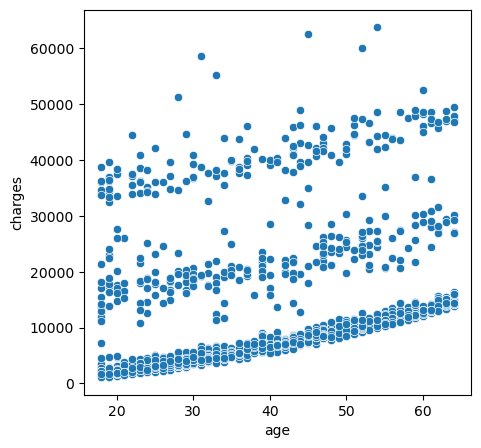

In [16]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='age',y='charges')
plt.show()

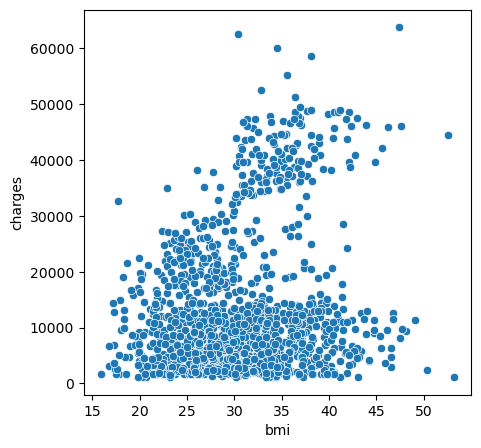

In [17]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='bmi',y='charges')
plt.show()

In [18]:
corr = num_data.corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<AxesSubplot:>

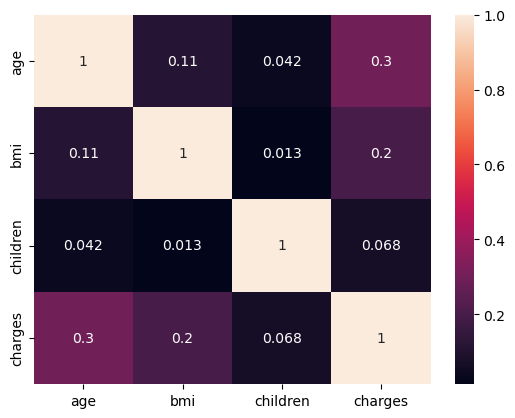

In [20]:
sns.heatmap(corr,annot=True)

In [23]:
df.loc[:,"charges"].skew()

1.5158796580240388

In [25]:
Q1 = df.loc[:,'charges'].quantile(0.25)
Q3 = df.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [27]:
df[df.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [28]:
df[df.loc[:,'charges']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [30]:
df[(df.loc[:,'charges']>upper_limit)|(df.loc[:,'charges']<lower_limit)]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [31]:
len(df[(df.loc[:,'charges']>upper_limit)|(df.loc[:,'charges']<lower_limit)])/len(df)*100

10.388639760837071

In [32]:
std_val = df.loc[:,'bmi'].std()
mean_val = df.loc[:,'bmi'].mean()
lower_limit = mean_val-3*std_val
upper_limit = mean_val+3*std_val

In [33]:
df[df.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [34]:
df[df.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [36]:
df.loc[df.loc[:,'bmi']>upper_limit,'bmi'] = df.loc[:,'bmi'].mean()

In [37]:
df[df.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges


In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.loc[:,'Smoker'] = le.fit_transform(df.loc[:,'smoker'])

In [42]:
df.dtypes


age           int64
sex          object
bmi         float64
children      int64
smoker        int32
region       object
charges     float64
Smoker        int64
dtype: object

In [43]:
df.drop(columns = 'smoker',inplace=True)

In [45]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
region       object
charges     float64
Smoker        int64
dtype: object